In [2]:
import pandas as pd

file_path = 'dane/cleaned_data.csv'
df_modeling = pd.read_csv(file_path)
df_modeling.head()

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\Adam\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Adam\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
texts = df_modeling['Semantic_Text'].tolist()

embeddings = model.encode(texts, show_progress_bar=True)
df_modeling['Embeddings'] = list(embeddings)

Batches:   0%|          | 0/678 [00:00<?, ?it/s]

In [5]:
print(f"\nWymiary wygenerowanej macierzy wektorów: {embeddings.shape}")
print("\nPróbka wektora dla pierwszych perfum (pierwsze 5 z 384 liczb):")
print(df_modeling['Embeddings'].iloc[0][:5])


Wymiary wygenerowanej macierzy wektorów: (21692, 384)

Próbka wektora dla pierwszych perfum (pierwsze 5 z 384 liczb):
[-0.18018202 -0.0118093   0.08470965  0.3962452   0.30952036]


1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...


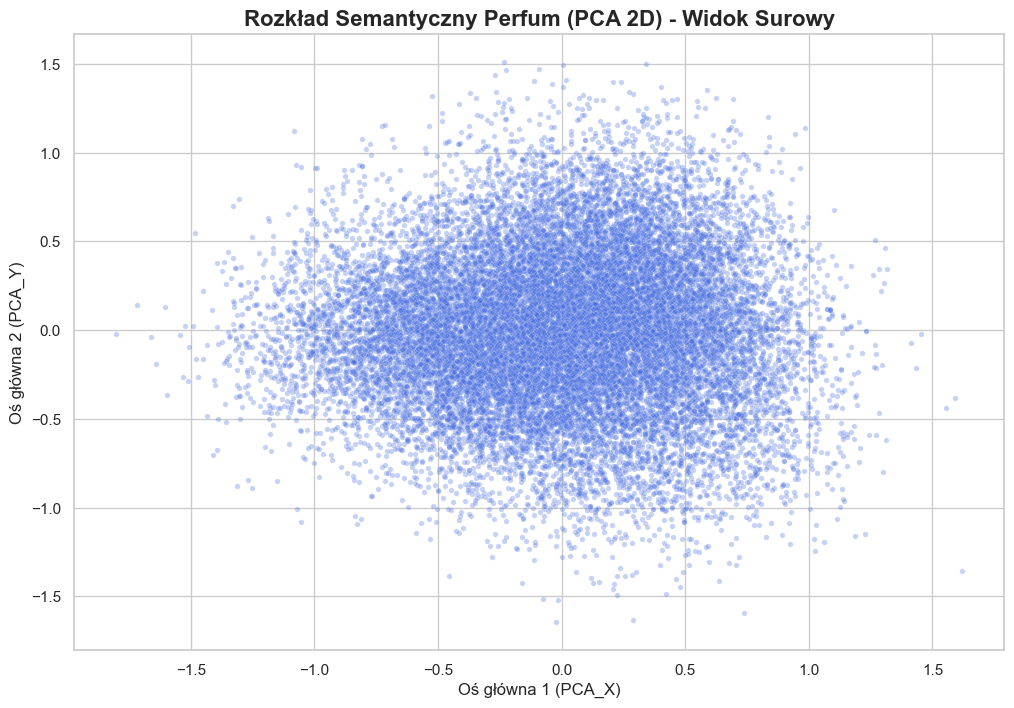

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

X_embeddings = np.array(df_modeling['Embeddings'].tolist())

print("1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embeddings)

df_modeling['PCA_X'] = X_pca[:, 0]
df_modeling['PCA_Y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    alpha=0.3, 
    s=15, 
    color='royalblue'
)

plt.title('Rozkład Semantyczny Perfum (PCA 2D) - Widok Surowy', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.show()

Liczba klastrów (grup): 5
Wynik Silhouette Score: 0.3177


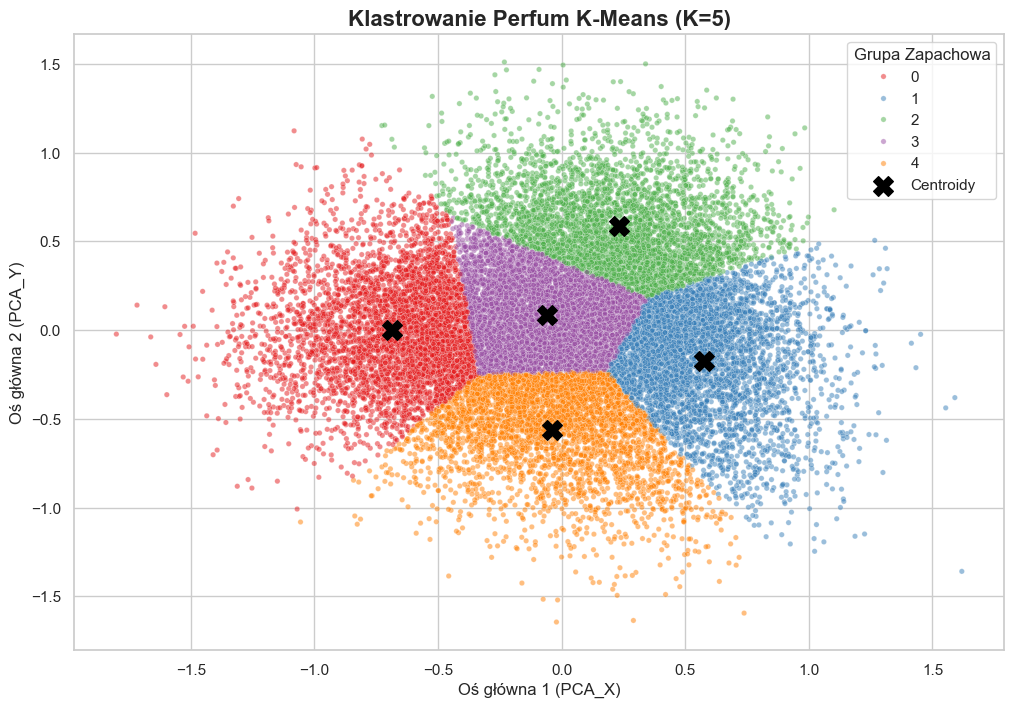

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init="auto")

df_modeling['Cluster_ID'] = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])

sil_score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], df_modeling['Cluster_ID'])

print(f"Liczba klastrów (grup): {num_clusters}")
print(f"Wynik Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    hue=df_modeling['Cluster_ID'], 
    palette='Set1', 
    alpha=0.5, 
    s=15
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroidy')

plt.title(f'Klastrowanie Perfum K-Means (K={num_clusters})', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.legend(title='Grupa Zapachowa')
plt.show()

In [ ]:
### spróbować wydobyć mniejszy zbiór np losowy albo dla najpopularniejszych marek aby łatwiej było zobaczyć podział na klastry i wtedy dodać do każego punktu etykiety, następnie wyciągnąć wnioski co do wygenerowanych wektorów